# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sarahnjunge/starter-notebooks/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Research question

Which content pages should a content team review first because their observed search-performance signals suggest they may need attention?

## Decision supported

The model is designed to help a content team prioritize a limited review queue.

Instead of reviewing pages at random, the team can use observed historical performance signals to create a ranked list of pages for human review.

The output is decision support, not a claim that a page will definitely decline or that a particular signal caused the change.

In [30]:
print("CAPSTONE QUESTION")
print("Which content pages should a content team review first?")
print()
print("Decision: prioritize pages for human content review")
print("Framing: observed signals and decision support")

CAPSTONE QUESTION
Which content pages should a content team review first?

Decision: prioritize pages for human content review
Framing: observed signals and decision support


## Data

This project uses the FlyRank internship warehouse release hosted as Parquet data.

The primary source is the content-level daily search-performance table. Supporting tables are used where they provide information available at the prediction time.

The analysis uses historical observations to construct features and a later period to measure the outcome. Future outcome information is excluded from the model features to prevent leakage.

Client names, domains, URLs, private search queries, credentials, and raw private exports are not used in the public-facing analysis.

In [31]:

# Connect to the FlyRank internship warehouse

import os
import getpass
import duckdb

HF_TOKEN = os.environ.get("HF_TOKEN") or getpass.getpass(
    "Paste your Hugging Face READ token (hf_...): "
)

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("Warehouse connection: OK")
print("FlyRank release: internship-warehouse")

Paste your Hugging Face READ token (hf_...): ··········
Warehouse connection: OK
FlyRank release: internship-warehouse


In [32]:
# Inspect the size and date range of the capstone data

print("=== TABLE SIZES ===")

for name, table in TABLES.items():
    count = con.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]
    print(f"{name}: {count:,} rows")

print()
print("=== DAILY SEARCH PERFORMANCE DATE RANGE ===")

daily_range = con.execute(f"""
    SELECT
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS number_of_dates
    FROM {TABLES['fact_daily']}
""").fetchone()

print(f"First date: {daily_range[0]}")
print(f"Last date: {daily_range[1]}")
print(f"Number of dates: {daily_range[2]:,}")

print()
print("=== QUERY TABLE DATE RANGE ===")

query_range = con.execute(f"""
    SELECT
        MIN(window_start) AS first_window,
        MAX(window_end) AS last_window
    FROM {TABLES['fact_query_90d']}
""").fetchone()

print(f"First query window: {query_range[0]}")
print(f"Last query window: {query_range[1]}")

=== TABLE SIZES ===
dim_clients: 104 rows
dim_content: 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily: 78,835,655 rows
fact_query_90d: 2,414,248 rows

=== DAILY SEARCH PERFORMANCE DATE RANGE ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

First date: 2025-01-27
Last date: 2026-06-30
Number of dates: 520

=== QUERY TABLE DATE RANGE ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

First query window: 2026-04-02
Last query window: 2026-06-30


In [33]:
# Inspect the columns in the daily search-performance table

daily_columns = con.execute(f"""
    SELECT *
    FROM {TABLES['fact_daily']}
    LIMIT 0
""").description

print("=== DAILY TABLE COLUMNS ===")

for col in daily_columns:
    print(col[0])

=== DAILY TABLE COLUMNS ===
report_date
client_hash_id
content_hash_id
client_has_gsc
client_has_ga4
gsc_data_available
ga4_data_available
gsc_impressions
gsc_clicks
gsc_sum_position
gsc_avg_position
ga4_pageviews
ga4_sessions
ga4_users
ga4_engaged_sessions
ga4_total_engagement_sec
sessions_organic
sessions_direct
sessions_referral
sessions_social
sessions_paid
sessions_ai
ai_chatgpt
ai_perplexity
ai_gemini
ai_copilot
ai_claude
ai_meta
ai_other
scroll_events
month


In [34]:
# Check how much of the daily data has usable Google Search Console signals

availability_check = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_available_rows,

        COUNT(*) FILTER (
            WHERE gsc_impressions IS NOT NULL
        ) AS rows_with_impressions,

        COUNT(*) FILTER (
            WHERE gsc_clicks IS NOT NULL
        ) AS rows_with_clicks,

        COUNT(*) FILTER (
            WHERE gsc_avg_position IS NOT NULL
        ) AS rows_with_position

    FROM {TABLES['fact_daily']}
""").fetchone()

print("=== GSC DATA AVAILABILITY ===")
print(f"Total rows:              {availability_check[0]:,}")
print(f"GSC available rows:      {availability_check[1]:,}")
print(f"Rows with impressions:   {availability_check[2]:,}")
print(f"Rows with clicks:        {availability_check[3]:,}")
print(f"Rows with avg position:  {availability_check[4]:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== GSC DATA AVAILABILITY ===
Total rows:              78,835,655
GSC available rows:      28,970,051
Rows with impressions:   78,737,649
Rows with clicks:        78,737,649
Rows with avg position:  28,970,001


In [6]:
# Check how much historical data each content page has

page_history = con.execute(f"""
    SELECT
        content_hash_id,
        COUNT(*) AS total_days,
        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_days,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date
    FROM {TABLES['fact_daily']}
    GROUP BY content_hash_id
""").fetchdf()

print("=== PAGE HISTORY COVERAGE ===")

print(f"Unique pages: {len(page_history):,}")
print()

print("Total days per page:")
print(page_history["total_days"].describe().to_string())

print()
print("GSC-available days per page:")
print(page_history["gsc_days"].describe().to_string())

print()
print("Pages with at least 30 GSC days:",
      (page_history["gsc_days"] >= 30).sum())

print("Pages with at least 60 GSC days:",
      (page_history["gsc_days"] >= 60).sum())

print("Pages with at least 90 GSC days:",
      (page_history["gsc_days"] >= 90).sum())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== PAGE HISTORY COVERAGE ===
Unique pages: 427,292

Total days per page:
count    427292.000000
mean        184.500658
std          93.721777
min           3.000000
25%         112.000000
50%         218.000000
75%         240.000000
max         520.000000

GSC-available days per page:
count    427292.000000
mean         67.799189
std         101.830136
min           0.000000
25%           0.000000
50%          15.000000
75%         100.000000
max         520.000000

Pages with at least 30 GSC days: 184905
Pages with at least 60 GSC days: 144984
Pages with at least 90 GSC days: 114985


In [7]:
# Find dates that have enough history for a 90-day feature window
# followed by a 30-day outcome window.

date_check = con.execute(f"""
    SELECT
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,

        MIN(report_date) + INTERVAL '89 days' AS first_possible_feature_end,

        MAX(report_date) - INTERVAL '30 days' AS last_possible_feature_end
    FROM {TABLES['fact_daily']}
""").fetchone()

print("=== CAPSTONE TIME WINDOW ===")
print(f"Warehouse starts:              {date_check[0]}")
print(f"Warehouse ends:                {date_check[1]}")
print(f"First possible 90-day endpoint: {date_check[2]}")
print(f"Last possible 90-day endpoint:  {date_check[3]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== CAPSTONE TIME WINDOW ===
Warehouse starts:              2025-01-27
Warehouse ends:                2026-06-30
First possible 90-day endpoint: 2025-04-26 00:00:00
Last possible 90-day endpoint:  2026-05-31 00:00:00


In [8]:
# Check GSC coverage by month

monthly_coverage = con.execute(f"""
    SELECT
        DATE_TRUNC('month', report_date) AS month,
        COUNT(*) AS total_rows,
        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_rows,
        COUNT(DISTINCT content_hash_id) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS pages_with_gsc
    FROM {TABLES['fact_daily']}
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

print("=== MONTHLY GSC COVERAGE ===")
print(monthly_coverage.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== MONTHLY GSC COVERAGE ===
     month  total_rows  gsc_rows  pages_with_gsc
2025-01-01        1297      1297             476
2025-02-01       75985     75985            5903
2025-03-01      167859    167859           10374
2025-04-01      285114    285114           13046
2025-05-01      349923    349923           14887
2025-06-01      329201    329201           16399
2025-07-01      469794    469794           27945
2025-08-01      704962    704962           37204
2025-09-01      845813    845813           53127
2025-10-01     2165471   1187654           64906
2025-11-01     6793825   1681368           99403
2025-12-01     7752930   2087675          109639
2026-01-01     7890817   2397143          121544
2026-02-01     7355108   2621783          153559
2026-03-01     9841378   3611061          176738
2026-04-01    10424730   3901060          194760
2026-05-01    11687376   4373422          237910
2026-06-01    11694072   3878937          208636


In [9]:
# Check page-level GSC coverage for the first candidate feature window

feature_end = "2026-03-31"
feature_start = "2026-01-01"

coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT content_hash_id) AS pages_seen,

        COUNT(DISTINCT content_hash_id) FILTER (
            WHERE gsc_days >= 60
        ) AS pages_with_60_plus_days,

        COUNT(DISTINCT content_hash_id) FILTER (
            WHERE gsc_days >= 90
        ) AS pages_with_90_days

    FROM (
        SELECT
            content_hash_id,
            COUNT(*) FILTER (
                WHERE gsc_data_available = TRUE
            ) AS gsc_days
        FROM {TABLES['fact_daily']}
        WHERE report_date BETWEEN DATE '{feature_start}'
                              AND DATE '{feature_end}'
        GROUP BY content_hash_id
    )
""").fetchone()

print("=== CANDIDATE FEATURE WINDOW ===")
print(f"Feature start:              {feature_start}")
print(f"Feature end:                {feature_end}")
print(f"Pages seen:                 {coverage[0]:,}")
print(f"Pages with 60+ GSC days:    {coverage[1]:,}")
print(f"Pages with 90 GSC days:     {coverage[2]:,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== CANDIDATE FEATURE WINDOW ===
Feature start:              2026-01-01
Feature end:                2026-03-31
Pages seen:                 349,411
Pages with 60+ GSC days:    70,432
Pages with 90 GSC days:     34,057


In [10]:
# Check GSC coverage during the 30-day outcome window

outcome_start = "2026-04-01"
outcome_end = "2026-04-30"

outcome_coverage = con.execute(f"""
    SELECT
        COUNT(DISTINCT content_hash_id) AS pages_seen,

        COUNT(DISTINCT content_hash_id) FILTER (
            WHERE gsc_days >= 15
        ) AS pages_with_15_plus_days,

        COUNT(DISTINCT content_hash_id) FILTER (
            WHERE gsc_days >= 30
        ) AS pages_with_30_days

    FROM (
        SELECT
            content_hash_id,
            COUNT(*) FILTER (
                WHERE gsc_data_available = TRUE
            ) AS gsc_days
        FROM {TABLES['fact_daily']}
        WHERE report_date BETWEEN DATE '{outcome_start}'
                              AND DATE '{outcome_end}'
        GROUP BY content_hash_id
    )
""").fetchone()

print("=== OUTCOME WINDOW ===")
print(f"Outcome start:              {outcome_start}")
print(f"Outcome end:                {outcome_end}")
print(f"Pages seen:                 {outcome_coverage[0]:,}")
print(f"Pages with 15+ GSC days:    {outcome_coverage[1]:,}")
print(f"Pages with 30 GSC days:     {outcome_coverage[2]:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== OUTCOME WINDOW ===
Outcome start:              2026-04-01
Outcome end:                2026-04-30
Pages seen:                 362,172
Pages with 15+ GSC days:    130,341
Pages with 30 GSC days:     74,572


In [11]:
# Build leakage-safe page-level features from the 90-day historical window

feature_start = "2026-01-01"
feature_end = "2026-03-31"

features = con.execute(f"""
    SELECT
        content_hash_id,
        client_hash_id,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS gsc_days,

        -- Search visibility
        SUM(gsc_impressions) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS impressions_90d,

        SUM(gsc_clicks) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS clicks_90d,

        -- Average CTR across the observed period
        SUM(gsc_clicks) FILTER (
            WHERE gsc_data_available = TRUE
        ) / NULLIF(
            SUM(gsc_impressions) FILTER (
                WHERE gsc_data_available = TRUE
            ), 0
        ) AS ctr_90d,

        -- Average search position
        AVG(gsc_avg_position) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS avg_position_90d,

        -- Variation in search position
        STDDEV_SAMP(gsc_avg_position) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS position_volatility_90d,

        -- Average daily search performance
        AVG(gsc_impressions) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS avg_daily_impressions,

        AVG(gsc_clicks) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS avg_daily_clicks

    FROM {TABLES['fact_daily']}

    WHERE report_date BETWEEN DATE '{feature_start}'
                          AND DATE '{feature_end}'

    GROUP BY
        content_hash_id,
        client_hash_id

    HAVING
        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) >= 60
""").fetchdf()

print("=== FEATURE TABLE ===")
print(f"Feature rows: {len(features):,}")
print()
print("Columns:")
print(features.columns.tolist())
print()
print("Sample:")
print(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== FEATURE TABLE ===
Feature rows: 70,432

Columns:
['content_hash_id', 'client_hash_id', 'gsc_days', 'impressions_90d', 'clicks_90d', 'ctr_90d', 'avg_position_90d', 'position_volatility_90d', 'avg_daily_impressions', 'avg_daily_clicks']

Sample:
            content_hash_id           client_hash_id  gsc_days  \
0  content_cc02e6a397d2ffc2  client_e547b89c05043229        88   
1  content_b2c8677f822e152a  client_e547b89c05043229        88   
2  content_c6ac71d72dbccc86  client_e547b89c05043229        88   
3  content_7916e8f527f1c672  client_e547b89c05043229        88   
4  content_c4a9f203b6708ddf  client_e547b89c05043229        88   

   impressions_90d  clicks_90d   ctr_90d  avg_position_90d  \
0           7106.0        28.0  0.003940          3.754591   
1          14292.0        66.0  0.004618          6.645100   
2           1533.0         3.0  0.001957          6.121017   
3            836.0         1.0  0.001196         30.540296   
4           6557.0        10.0  0.001525     

In [12]:
# Build the 30-day future outcome for the same pages
# Outcome period: April 2026
#
# We compare April impressions with March impressions.
# This is an observed directional measure, not a causal claim.

outcomes = con.execute(f"""
    SELECT
        content_hash_id,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS outcome_gsc_days,

        SUM(gsc_impressions) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS impressions_april,

        SUM(gsc_clicks) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS clicks_april

    FROM {TABLES['fact_daily']}

    WHERE report_date BETWEEN DATE '2026-04-01'
                          AND DATE '2026-04-30'

    GROUP BY content_hash_id

    HAVING
        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) >= 15
""").fetchdf()

print("=== APRIL OUTCOME TABLE ===")
print(f"Outcome rows: {len(outcomes):,}")
print()
print(outcomes.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== APRIL OUTCOME TABLE ===
Outcome rows: 130,341

            content_hash_id  outcome_gsc_days  impressions_april  clicks_april
0  content_84969ada15a78938                29              182.0           0.0
1  content_e2f8790fe6ea637e                30              245.0           0.0
2  content_11ee386ea3835e18                19               84.0           0.0
3  content_9715fb7b56c5fecd                30              342.0           1.0
4  content_84ef11ddeffb8136                28              121.0           0.0


In [13]:
# Calculate March's 30-day impressions and create the observed outcome label

march_baseline = con.execute(f"""
    SELECT
        content_hash_id,

        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS march_gsc_days,

        SUM(gsc_impressions) FILTER (
            WHERE gsc_data_available = TRUE
        ) AS impressions_march

    FROM {TABLES['fact_daily']}

    WHERE report_date BETWEEN DATE '2026-03-01'
                          AND DATE '2026-03-31'

    GROUP BY content_hash_id

    HAVING
        COUNT(*) FILTER (
            WHERE gsc_data_available = TRUE
        ) >= 15
""").fetchdf()

# Join March baseline with April outcome
outcome_table = march_baseline.merge(
    outcomes,
    on="content_hash_id",
    how="inner"
)

# Calculate the directional change
outcome_table["impression_change_pct"] = (
    (outcome_table["impressions_april"] -
     outcome_table["impressions_march"])
    / outcome_table["impressions_march"].replace(0, float("nan"))
)

# Define the observed decline label
outcome_table["needs_attention"] = (
    outcome_table["impression_change_pct"] < -0.20
).astype(int)

print("=== OUTCOME LABEL ===")
print(f"March baseline rows: {len(march_baseline):,}")
print(f"Matched March → April pages: {len(outcome_table):,}")
print()
print("Outcome distribution:")
print(outcome_table["needs_attention"].value_counts().sort_index())
print()
print("Percentage needing attention:")
print(
    f"{outcome_table['needs_attention'].mean() * 100:.2f}%"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== OUTCOME LABEL ===
March baseline rows: 118,549
Matched March → April pages: 108,027

Outcome distribution:
needs_attention
0    54893
1    53134
Name: count, dtype: int64

Percentage needing attention:
49.19%


In [14]:
# Inspect the observed April performance changes

print("=== MARCH IMPRESSIONS ===")
print(
    outcome_table["impressions_march"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_string()
)

print()
print("=== APRIL IMPRESSIONS ===")
print(
    outcome_table["impressions_april"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_string()
)

print()
print("=== IMPRESSION CHANGE % ===")
print(
    outcome_table["impression_change_pct"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_string()
)

print()
print("=== CURRENT LABEL AT DIFFERENT THRESHOLDS ===")

for threshold in [-0.10, -0.20, -0.30, -0.40, -0.50]:
    rate = (
        outcome_table["impression_change_pct"] < threshold
    ).mean() * 100

    print(f"Decline threshold {threshold:.0%}: {rate:.2f}%")

=== MARCH IMPRESSIONS ===
count    108027.000000
mean       2553.676025
std        6764.995446
min          16.000000
25%         200.000000
50%         649.000000
75%        2276.000000
90%        6039.400000
95%       10613.700000
99%       28356.220000
max      617124.000000

=== APRIL IMPRESSIONS ===
count    108027.000000
mean       2483.283318
std        7346.172294
min          16.000000
25%         143.000000
50%         502.000000
75%        1953.000000
90%        5978.000000
95%       11576.700000
99%       29118.440000
max      799358.000000

=== IMPRESSION CHANGE % ===
count    108027.000000
mean          0.070745
std           1.360190
min          -0.997757
1%           -0.882223
5%           -0.758110
10%          -0.665455
25%          -0.465972
50%          -0.190476
75%           0.213633
90%           0.918676
95%           1.737127
99%           4.128989
max         128.712500

=== CURRENT LABEL AT DIFFERENT THRESHOLDS ===
Decline threshold -10%: 57.06%
Decline thre

In [15]:
# Test the decline label after requiring a minimum amount of
# March search activity.

print("=== LABEL SENSITIVITY TO MINIMUM MARCH IMPRESSIONS ===")

for min_impressions in [50, 100, 200, 500, 1000]:

    eligible = outcome_table[
        outcome_table["impressions_march"] >= min_impressions
    ].copy()

    decline_rate = (
        eligible["impression_change_pct"] < -0.20
    ).mean() * 100

    print(
        f"Minimum March impressions: {min_impressions:>4} | "
        f"Pages: {len(eligible):>7,} | "
        f"Decline rate: {decline_rate:>6.2f}%"
    )

=== LABEL SENSITIVITY TO MINIMUM MARCH IMPRESSIONS ===
Minimum March impressions:   50 | Pages: 103,889 | Decline rate:  50.48%
Minimum March impressions:  100 | Pages:  94,596 | Decline rate:  51.48%
Minimum March impressions:  200 | Pages:  81,075 | Decline rate:  51.59%
Minimum March impressions:  500 | Pages:  60,239 | Decline rate:  50.63%
Minimum March impressions: 1000 | Pages:  44,180 | Decline rate:  49.21%


In [16]:
# Combine historical features with the future outcome
# and apply the minimum activity requirement.

model_data = features.merge(
    outcome_table[
        [
            "content_hash_id",
            "march_gsc_days",
            "impressions_march",
            "outcome_gsc_days",
            "impressions_april",
            "impression_change_pct",
            "needs_attention"
        ]
    ],
    on="content_hash_id",
    how="inner"
)

# Keep pages with enough March search activity
model_data = model_data[
    model_data["impressions_march"] >= 100
].copy()

print("=== FINAL MODELING DATASET ===")
print(f"Rows: {len(model_data):,}")
print()

print("Target distribution:")
print(
    model_data["needs_attention"]
    .value_counts()
    .sort_index()
)

print()
print("Target percentage:")
print(
    model_data["needs_attention"]
    .mean() * 100
)

print()
print("Feature columns:")
print(features.columns.tolist())

=== FINAL MODELING DATASET ===
Rows: 63,597

Target distribution:
needs_attention
0    28652
1    34945
Name: count, dtype: int64

Target percentage:
54.94756041951664

Feature columns:
['content_hash_id', 'client_hash_id', 'gsc_days', 'impressions_90d', 'clicks_90d', 'ctr_90d', 'avg_position_90d', 'position_volatility_90d', 'avg_daily_impressions', 'avg_daily_clicks']


In [17]:
# Baseline: prioritize pages with the highest historical impressions.
#
# This uses only information available before the April outcome period.

from sklearn.model_selection import GroupShuffleSplit

# Use the same client-grouped split that we will later use for the model.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_data,
        groups=model_data["client_hash_id"]
    )
)

train_data = model_data.iloc[train_idx].copy()
test_data = model_data.iloc[test_idx].copy()

# Rank test pages by historical 90-day impressions
baseline_ranked = test_data.sort_values(
    "impressions_90d",
    ascending=False
)

top_50_baseline = baseline_ranked.head(50)

precision_at_50_baseline = (
    top_50_baseline["needs_attention"].sum() / 50
)

print("=== BASELINE ===")
print(f"Training rows: {len(train_data):,}")
print(f"Test rows:     {len(test_data):,}")
print()
print("Baseline: rank by historical 90-day impressions")
print(f"Precision@50: {precision_at_50_baseline:.3f}")
print(
    f"Pages needing attention in top 50: "
    f"{top_50_baseline['needs_attention'].sum()}/50"
)

=== BASELINE ===
Training rows: 62,627
Test rows:     970

Baseline: rank by historical 90-day impressions
Precision@50: 0.760
Pages needing attention in top 50: 38/50


In [18]:
# Prepare leakage-safe features for the ML model

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

feature_cols = [
    "gsc_days",
    "impressions_90d",
    "clicks_90d",
    "ctr_90d",
    "avg_position_90d",
    "position_volatility_90d",
    "avg_daily_impressions",
    "avg_daily_clicks"
]

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]

y_train = train_data["needs_attention"]
y_test = test_data["needs_attention"]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("=== MODEL TRAINING ===")
print(f"Features: {len(feature_cols)}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print("Model: Logistic Regression")
print("Status: training complete")

=== MODEL TRAINING ===
Features: 8
Training rows: 62,627
Test rows: 970
Model: Logistic Regression
Status: training complete


In [19]:
# Rank test pages using the model's predicted probability
# and evaluate the top-50 review queue.

test_data = test_data.copy()

test_data["model_score"] = model.predict_proba(X_test)[:, 1]

model_ranked = test_data.sort_values(
    "model_score",
    ascending=False
)

top_50_model = model_ranked.head(50)

precision_at_50_model = (
    top_50_model["needs_attention"].sum() / 50
)

balanced_acc = balanced_accuracy_score(
    y_test,
    model.predict(X_test)
)

print("=== ML MODEL RESULTS ===")
print(f"Balanced accuracy: {balanced_acc:.3f}")
print(f"Precision@50:      {precision_at_50_model:.3f}")
print(
    f"Pages needing attention in top 50: "
    f"{top_50_model['needs_attention'].sum()}/50"
)

print()
print("=== BASELINE VS MODEL ===")
print(f"Baseline Precision@50: {precision_at_50_baseline:.3f}")
print(f"Model Precision@50:    {precision_at_50_model:.3f}")
print(
    f"Difference: "
    f"{precision_at_50_model - precision_at_50_baseline:+.3f}"
)

=== ML MODEL RESULTS ===
Balanced accuracy: 0.581
Precision@50:      0.860
Pages needing attention in top 50: 43/50

=== BASELINE VS MODEL ===
Baseline Precision@50: 0.760
Model Precision@50:    0.860
Difference: +0.100


In [20]:
# Inspect the highest-ranked pages

top_10 = model_ranked[
    [
        "content_hash_id",
        "client_hash_id",
        "model_score",
        "impressions_90d",
        "clicks_90d",
        "ctr_90d",
        "avg_position_90d",
        "position_volatility_90d",
        "impression_change_pct",
        "needs_attention"
    ]
].head(10)

print("=== TOP 10 MODEL-RANKED PAGES ===")
display(top_10)

=== TOP 10 MODEL-RANKED PAGES ===


,content_hash_id,client_hash_id,model_score,impressions_90d,clicks_90d,ctr_90d,avg_position_90d,position_volatility_90d,impression_change_pct,needs_attention
48292,content_dcfc1f02f71829cc,client_65de48885f4ef01b,0.691887,553.0,3.0,0.005425,13.453586,26.688375,0.054054,0
57332,content_03576e58446b644b,client_65de48885f4ef01b,0.669148,511.0,0.0,0.000000,5.000656,7.899071,-0.624242,1
43564,content_47e0e0206e5945ae,client_65de48885f4ef01b,0.660545,652.0,0.0,0.000000,10.104703,11.565588,-0.732601,1
44807,content_2d4a9a63aeded404,client_65de48885f4ef01b,0.657474,1776.0,0.0,0.000000,15.657860,14.507073,-0.752809,1
44837,content_1855d5fb5fb6a1a4,client_65de48885f4ef01b,0.643979,1304.0,0.0,0.000000,27.979236,24.282095,-0.291498,1
57208,content_8c8cffd039cd2b7f,client_65de48885f4ef01b,0.643945,1027.0,0.0,0.000000,12.299587,11.476512,-0.854271,1
48111,content_76689f1f8d209e67,client_65de48885f4ef01b,0.642601,640.0,0.0,0.000000,12.000168,11.537068,-0.566667,1
49502,content_685ba8c22f4666d5,client_400c21c81c8b46ef,0.633826,253.0,0.0,0.000000,13.774018,16.271040,-0.280702,1
49599,content_3c02b56c9043eca8,client_400c21c81c8b46ef,0.632554,501.0,0.0,0.000000,11.125383,13.777532,-0.707865,1
57382,content_92a735e687d9bcee,client_65de48885f4ef01b,0.628538,338.0,1.0,0.002959,9.093334,15.537849,-0.139706,0


In [21]:
# Evaluate the model at different review-queue sizes

queue_sizes = [10, 20, 50, 100, 200]

print("=== PRECISION AT DIFFERENT REVIEW QUEUE SIZES ===")

for k in queue_sizes:
    top_k = model_ranked.head(k)

    precision_at_k = top_k["needs_attention"].mean()

    print(
        f"Top-{k:>3}: "
        f"Precision = {precision_at_k:.3f} "
        f"({top_k['needs_attention'].sum()}/{k})"
    )

=== PRECISION AT DIFFERENT REVIEW QUEUE SIZES ===
Top- 10: Precision = 0.800 (8/10)
Top- 20: Precision = 0.850 (17/20)
Top- 50: Precision = 0.860 (43/50)
Top-100: Precision = 0.860 (86/100)
Top-200: Precision = 0.855 (171/200)


In [22]:
# Inspect which features contribute most strongly to the model

import pandas as pd

coefficients = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.named_steps["classifier"].coef_[0]
})

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

print("=== MODEL FEATURE COEFFICIENTS ===")
display(
    coefficients[
        ["feature", "coefficient"]
    ]
)

=== MODEL FEATURE COEFFICIENTS ===


,feature,coefficient
4,avg_position_90d,-0.372711
5,position_volatility_90d,0.298030
7,avg_daily_clicks,-0.279048
1,impressions_90d,0.244180
3,ctr_90d,-0.230932
6,avg_daily_impressions,-0.182059
0,gsc_days,0.121995
2,clicks_90d,-0.043828


In [23]:
# Compare the pages selected by the baseline and the ML model

baseline_ids = set(
    top_50_baseline["content_hash_id"]
)

model_ids = set(
    top_50_model["content_hash_id"]
)

overlap = baseline_ids.intersection(model_ids)

model_only = model_ids - baseline_ids
baseline_only = baseline_ids - model_ids

print("=== TOP-50 RANKING OVERLAP ===")
print(f"Baseline top-50: {len(baseline_ids)}")
print(f"Model top-50:    {len(model_ids)}")
print(f"Pages in both:   {len(overlap)}")
print(f"Model-only:      {len(model_only)}")
print(f"Baseline-only:   {len(baseline_only)}")

=== TOP-50 RANKING OVERLAP ===
Baseline top-50: 50
Model top-50:    50
Pages in both:   2
Model-only:      48
Baseline-only:   48


In [24]:
# Compare model-only and baseline-only pages

model_only_data = test_data[
    test_data["content_hash_id"].isin(model_only)
]

baseline_only_data = test_data[
    test_data["content_hash_id"].isin(baseline_only)
]

print("=== MODEL-ONLY TOP-50 PAGES ===")
print(
    f"Attention pages: "
    f"{model_only_data['needs_attention'].sum()}/"
    f"{len(model_only_data)}"
)
print(
    f"Precision: "
    f"{model_only_data['needs_attention'].mean():.3f}"
)

print()

print("=== BASELINE-ONLY TOP-50 PAGES ===")
print(
    f"Attention pages: "
    f"{baseline_only_data['needs_attention'].sum()}/"
    f"{len(baseline_only_data)}"
)
print(
    f"Precision: "
    f"{baseline_only_data['needs_attention'].mean():.3f}"
)

=== MODEL-ONLY TOP-50 PAGES ===
Attention pages: 41/48
Precision: 0.854

=== BASELINE-ONLY TOP-50 PAGES ===
Attention pages: 36/48
Precision: 0.750


In [25]:
# Final leakage audit
# Confirm that model features come only from the Jan-Mar feature window.

print("=== LEAKAGE AUDIT ===")

print("Feature window: 2026-01-01 to 2026-03-31")
print("Outcome window: 2026-04-01 to 2026-04-30")
print()

print("Features used by the model:")
for col in feature_cols:
    print(f"  ✓ {col}")

print()
print("April outcome columns kept only for evaluation:")
print("  ✓ impressions_april")
print("  ✓ impression_change_pct")
print("  ✓ needs_attention")

print()
print("April outcome variables are NOT included in feature_cols.")
print("Status: leakage check passed")

=== LEAKAGE AUDIT ===
Feature window: 2026-01-01 to 2026-03-31
Outcome window: 2026-04-01 to 2026-04-30

Features used by the model:
  ✓ gsc_days
  ✓ impressions_90d
  ✓ clicks_90d
  ✓ ctr_90d
  ✓ avg_position_90d
  ✓ position_volatility_90d
  ✓ avg_daily_impressions
  ✓ avg_daily_clicks

April outcome columns kept only for evaluation:
  ✓ impressions_april
  ✓ impression_change_pct
  ✓ needs_attention

April outcome variables are NOT included in feature_cols.
Status: leakage check passed


## Methodology

### Feature construction

For each content page, historical search-performance signals were aggregated over the 90-day feature window from January 1 to March 31, 2026.

The model used:

- GSC-observed days
- 90-day impressions
- 90-day clicks
- 90-day click-through rate
- average search position
- search-position volatility
- average daily impressions
- average daily clicks

Only pages with at least 60 GSC-observed days during the feature window were retained.

### Outcome definition

The evaluation outcome was measured during April 2026.

A page was labeled `needs_attention = 1` when its April impressions were more than 20% below its March impressions.

To reduce instability from very small impression counts, pages were required to have at least 100 March impressions.

This label represents an observed directional change in search impressions. It does not establish why the change occurred.

### Baseline

The baseline ranks pages by their historical 90-day impression volume and selects the top 50 pages for review.

This represents a simple volume-based prioritization strategy.

### Model

A Logistic Regression classifier was trained using the eight historical features above.

Missing feature values were median-imputed and the features were standardized before model fitting.

### Validation

The data was split using `GroupShuffleSplit` by `client_hash_id`, keeping pages from the same client in the same split.

This reduces the possibility that information from pages belonging to the same client appears in both training and test sets.

The model and baseline were evaluated on the same held-out test set.

### Primary metric

The primary metric is Precision@50 because the operational decision is to prioritize a limited review queue of 50 pages.

Precision@50 measures the proportion of the top 50 ranked pages that subsequently met the defined attention criterion.

Balanced accuracy is reported as a secondary classification metric.

### Leakage control

All model features were constructed from the January–March feature window.

April performance variables were used only to construct the evaluation outcome and were not included as model features.

## 4. Results (vs baseline)
## Results vs baseline

The Logistic Regression model produced a Precision@50 of **0.860** on the held-out test set, compared with **0.760** for the historical-impressions baseline.

This is a difference of **10 percentage points**.

In the top-50 review queue:

- The baseline identified 38 of 50 pages that met the attention criterion.
- The ML model identified 43 of 50 pages that met the attention criterion.

The model therefore surfaced five additional pages meeting the defined attention criterion within the same 50-page review budget.

The ranking also differed substantially from the baseline. Only 2 of the 50 pages appeared in both top-50 queues. Of the 48 pages selected by the model but not by the baseline, 41 met the attention criterion, giving that model-only group a Precision of **0.854**. The corresponding baseline-only group had 36 of 48 pages meeting the criterion, giving a Precision of **0.750**.

Precision remained between **0.85 and 0.86** for review queues from 20 to 200 pages, indicating that the observed ranking signal was not limited to the first few pages.

Balanced accuracy for the Logistic Regression classifier was **0.581**.

These results are measured on the held-out test set for the defined January–March feature window and April outcome window. They should be interpreted as evidence that the tested ranking approach performed differently from the baseline under this experimental setup, not as proof of causal effects or guaranteed future performance.

In [35]:
# Final results summary

print("=== CAPSTONE RESULTS ===")
print()
print(f"Baseline Precision@50: {precision_at_50_baseline:.3f}")
print(f"ML Precision@50:       {precision_at_50_model:.3f}")
print(f"Improvement:            {precision_at_50_model - precision_at_50_baseline:+.3f}")
print()
print(f"Baseline attention pages: {top_50_baseline['needs_attention'].sum()}/50")
print(f"ML attention pages:       {top_50_model['needs_attention'].sum()}/50")
print()
print(f"Top-50 overlap: {len(overlap)}/50")
print()
print(f"Model-only precision:    {model_only_data['needs_attention'].mean():.3f}")
print(f"Baseline-only precision: {baseline_only_data['needs_attention'].mean():.3f}")
print()
print(f"ML balanced accuracy:     {balanced_acc:.3f}")

=== CAPSTONE RESULTS ===

Baseline Precision@50: 0.760
ML Precision@50:       0.860
Improvement:            +0.100

Baseline attention pages: 38/50
ML attention pages:       43/50

Top-50 overlap: 2/50

Model-only precision:    0.854
Baseline-only precision: 0.750

ML balanced accuracy:     0.581


## 5. Limitations

## Limitations

This analysis supports a page-review prioritization workflow, but several limitations should be considered.

### 1. The outcome is directional

The `needs_attention` label is based on whether April impressions were more than 20% below March impressions.

A decline in impressions does not establish why the decline occurred. The model therefore identifies pages with an observed performance change rather than diagnosing its cause.

### 2. The model does not establish causality

The features describe historical search-performance patterns. A relationship between a feature and the model's attention score does not mean that changing that feature would cause performance to improve.

The analysis also does not establish that refreshing a page will reverse an observed decline.

### 3. The evaluation covers one time period

The model was evaluated using January–March 2026 features and an April 2026 outcome window.

Performance may differ across other time periods, clients, industries, or search environments. Additional temporal validation would be needed to assess how stable the result is over time.

### 4. The test set is client-held-out, not a future deployment test

The GroupShuffleSplit keeps clients separated between training and testing, which reduces cross-client leakage.

However, this is still a single held-out experiment rather than a true forward-time deployment evaluation.

### 5. Search data availability is uneven

GSC data is not available for every page and every day in the warehouse.

The analysis therefore uses pages with sufficient GSC-observed history and should not be interpreted as representing every page in the warehouse.

### 6. The review threshold is a modeling choice

The 20% impression-decline threshold and the minimum 100 March impressions were chosen to create a practical and less noisy evaluation target.

Different thresholds could produce different labels and different model performance.

### 7. The model is not a complete content recommendation system

The current model prioritizes pages for human review.

It does not determine the specific content changes that should be made, nor does it measure whether a recommended refresh subsequently improves performance.

### 8. Public interpretation should remain anonymized

The warehouse contains client and content identifiers. The public-facing research output should not expose client names, domains, URLs, private search queries, credentials, or other identifying information.

The model output should therefore be presented as an anonymized research workflow rather than as a list of real client recommendations.

In [27]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 6. Ranked recommendations
## Ranked recommendations

The model produces a ranked list of content pages using the predicted probability of meeting the defined attention criterion.

The highest-scoring pages are placed at the top of a review queue. This allows a content team with limited review capacity to focus first on pages whose historical search-performance signals indicate a higher observed risk of impression decline.

### Review prioritization

Pages are grouped into three review tiers based on their model scores:

- **High priority:** pages in the top 50 of the model ranking. These are considered first for human review.
- **Medium priority:** pages ranked 51–100. These form the next review group when additional capacity is available.
- **Lower priority:** pages ranked below 100. These remain eligible for review based on business context or new evidence.

These tiers are operational queue categories, not definitive judgments about content quality or future performance.

### Human review playbook

For each prioritized page, a reviewer should:

1. Check the recent impressions and clicks trend against the historical period.
2. Examine click-through rate and average search position for possible changes in search visibility or user response.
3. Review position volatility to determine whether performance has been unstable.
4. Inspect the page itself for outdated information, content gaps, relevance, and technical issues.
5. Record the review decision, the evidence considered, and any action taken.

### Interpretation

The ranking is intended to guide where human attention is allocated. It does not automatically prescribe a content refresh, prove that a page is declining because of its content, or guarantee that an intervention will improve performance.

The recommended action should be determined by a human reviewer after examining the page and its context.

In [36]:
# Create the ranked review queue

recommendations = model_ranked.copy().reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1

recommendations["priority"] = recommendations["rank"].apply(
    lambda rank: (
        "High" if rank <= 50
        else "Medium" if rank <= 100
        else "Lower"
    )
)

recommendations["review_reason"] = recommendations.apply(
    lambda row: (
        "Observed April impression decline"
        if row["needs_attention"] == 1
        else "Review historical signals and page context"
    ),
    axis=1
)

review_queue = recommendations[
    [
        "rank",
        "priority",
        "model_score",
        "impressions_90d",
        "clicks_90d",
        "ctr_90d",
        "avg_position_90d",
        "position_volatility_90d",
        "review_reason"
    ]
].copy()

print("=== RANKED REVIEW QUEUE ===")
display(review_queue.head(20))

print()
print("=== PRIORITY COUNTS ===")
print(review_queue["priority"].value_counts())


=== RANKED REVIEW QUEUE ===


,rank,priority,model_score,impressions_90d,clicks_90d,ctr_90d,avg_position_90d,position_volatility_90d,review_reason
0,1,High,0.691887,553.0,3.0,0.005425,13.453586,26.688375,Review historical signals and page context
1,2,High,0.669148,511.0,0.0,0.000000,5.000656,7.899071,Observed April impression decline
2,3,High,0.660545,652.0,0.0,0.000000,10.104703,11.565588,Observed April impression decline
3,4,High,0.657474,1776.0,0.0,0.000000,15.657860,14.507073,Observed April impression decline
4,5,High,0.643979,1304.0,0.0,0.000000,27.979236,24.282095,Observed April impression decline
5,6,High,0.643945,1027.0,0.0,0.000000,12.299587,11.476512,Observed April impression decline
6,7,High,0.642601,640.0,0.0,0.000000,12.000168,11.537068,Observed April impression decline
7,8,High,0.633826,253.0,0.0,0.000000,13.774018,16.271040,Observed April impression decline
8,9,High,0.632554,501.0,0.0,0.000000,11.125383,13.777532,Observed April impression decline
9,10,High,0.628538,338.0,1.0,0.002959,9.093334,15.537849,Review historical signals and page context



=== PRIORITY COUNTS ===
priority
Lower     870
High       50
Medium     50
Name: count, dtype: int64


In [37]:
# Create deployment-safe review reasons.
# These reasons use only historical feature values available
# during the Jan-Mar feature window.

recommendations = model_ranked.copy().reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1

recommendations["priority"] = recommendations["rank"].apply(
    lambda rank: (
        "High" if rank <= 50
        else "Medium" if rank <= 100
        else "Lower"
    )
)

def generate_review_reason(row):
    reasons = []

    if row["ctr_90d"] < 0.01:
        reasons.append("low historical CTR")

    if row["avg_position_90d"] > 10:
        reasons.append("historical average position above 10")

    if row["position_volatility_90d"] > 10:
        reasons.append("high position volatility")

    if row["avg_daily_clicks"] < 1:
        reasons.append("low historical daily clicks")

    if not reasons:
        reasons.append("combined historical performance signals")

    return "; ".join(reasons[:2])


recommendations["review_reason"] = recommendations.apply(
    generate_review_reason,
    axis=1
)

review_queue = recommendations[
    [
        "rank",
        "priority",
        "model_score",
        "impressions_90d",
        "clicks_90d",
        "ctr_90d",
        "avg_position_90d",
        "position_volatility_90d",
        "review_reason"
    ]
].copy()

print("=== DEPLOYMENT-SAFE REVIEW QUEUE ===")
display(review_queue.head(20))

=== DEPLOYMENT-SAFE REVIEW QUEUE ===


,rank,priority,model_score,impressions_90d,clicks_90d,ctr_90d,avg_position_90d,position_volatility_90d,review_reason
0,1,High,0.691887,553.0,3.0,0.005425,13.453586,26.688375,low historical CTR; historical average positio...
1,2,High,0.669148,511.0,0.0,0.000000,5.000656,7.899071,low historical CTR; low historical daily clicks
2,3,High,0.660545,652.0,0.0,0.000000,10.104703,11.565588,low historical CTR; historical average positio...
3,4,High,0.657474,1776.0,0.0,0.000000,15.657860,14.507073,low historical CTR; historical average positio...
4,5,High,0.643979,1304.0,0.0,0.000000,27.979236,24.282095,low historical CTR; historical average positio...
5,6,High,0.643945,1027.0,0.0,0.000000,12.299587,11.476512,low historical CTR; historical average positio...
6,7,High,0.642601,640.0,0.0,0.000000,12.000168,11.537068,low historical CTR; historical average positio...
7,8,High,0.633826,253.0,0.0,0.000000,13.774018,16.271040,low historical CTR; historical average positio...
8,9,High,0.632554,501.0,0.0,0.000000,11.125383,13.777532,low historical CTR; historical average positio...
9,10,High,0.628538,338.0,1.0,0.002959,9.093334,15.537849,low historical CTR; high position volatility


In [39]:
# Build an interpretable action playbook
# using only columns already present in review_queue.

def action_playbook(row):
    actions = []

    if row["ctr_90d"] < 0.01:
        actions.append("review title/meta and search-result relevance")

    if row["avg_position_90d"] > 10:
        actions.append("review search visibility and content relevance")

    if row["position_volatility_90d"] > 10:
        actions.append("investigate ranking stability")

    if row["clicks_90d"] == 0:
        actions.append("review pages with no historical clicks")

    if not actions:
        actions.append("review page context and historical performance")

    return " | ".join(actions[:2])


review_queue["recommended_review"] = review_queue.apply(
    action_playbook,
    axis=1
)

print("=== ACTION PLAYBOOK ===")

display(
    review_queue[
        [
            "rank",
            "priority",
            "model_score",
            "review_reason",
            "recommended_review"
        ]
    ].head(20)
)

=== ACTION PLAYBOOK ===


,rank,priority,model_score,review_reason,recommended_review
0,1,High,0.691887,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
1,2,High,0.669148,low historical CTR; low historical daily clicks,review title/meta and search-result relevance ...
2,3,High,0.660545,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
3,4,High,0.657474,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
4,5,High,0.643979,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
5,6,High,0.643945,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
6,7,High,0.642601,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
7,8,High,0.633826,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
8,9,High,0.632554,low historical CTR; historical average positio...,review title/meta and search-result relevance ...
9,10,High,0.628538,low historical CTR; high position volatility,review title/meta and search-result relevance ...


In [40]:
# Improve the action playbook so each page gets a clear,
# deployment-safe review prompt based only on historical signals.

def action_playbook(row):
    actions = []

    if row["ctr_90d"] < 0.01:
        actions.append("check search-result relevance and page title/meta")

    if row["avg_position_90d"] > 10:
        actions.append("check search visibility and content relevance")

    if row["position_volatility_90d"] > 10:
        actions.append("investigate ranking stability over the historical period")

    if row["clicks_90d"] == 0:
        actions.append("inspect why the page received impressions but no clicks")

    if not actions:
        actions.append("review page context and historical performance")

    return " | ".join(actions[:2])


review_queue["recommended_review"] = review_queue.apply(
    action_playbook,
    axis=1
)

print("=== FINAL ACTION PLAYBOOK ===")

display(
    review_queue[
        [
            "rank",
            "priority",
            "model_score",
            "review_reason",
            "recommended_review"
        ]
    ].head(20)
)

=== FINAL ACTION PLAYBOOK ===


,rank,priority,model_score,review_reason,recommended_review
0,1,High,0.691887,low historical CTR; historical average positio...,check search-result relevance and page title/m...
1,2,High,0.669148,low historical CTR; low historical daily clicks,check search-result relevance and page title/m...
2,3,High,0.660545,low historical CTR; historical average positio...,check search-result relevance and page title/m...
3,4,High,0.657474,low historical CTR; historical average positio...,check search-result relevance and page title/m...
4,5,High,0.643979,low historical CTR; historical average positio...,check search-result relevance and page title/m...
5,6,High,0.643945,low historical CTR; historical average positio...,check search-result relevance and page title/m...
6,7,High,0.642601,low historical CTR; historical average positio...,check search-result relevance and page title/m...
7,8,High,0.633826,low historical CTR; historical average positio...,check search-result relevance and page title/m...
8,9,High,0.632554,low historical CTR; historical average positio...,check search-result relevance and page title/m...
9,10,High,0.628538,low historical CTR; high position volatility,check search-result relevance and page title/m...


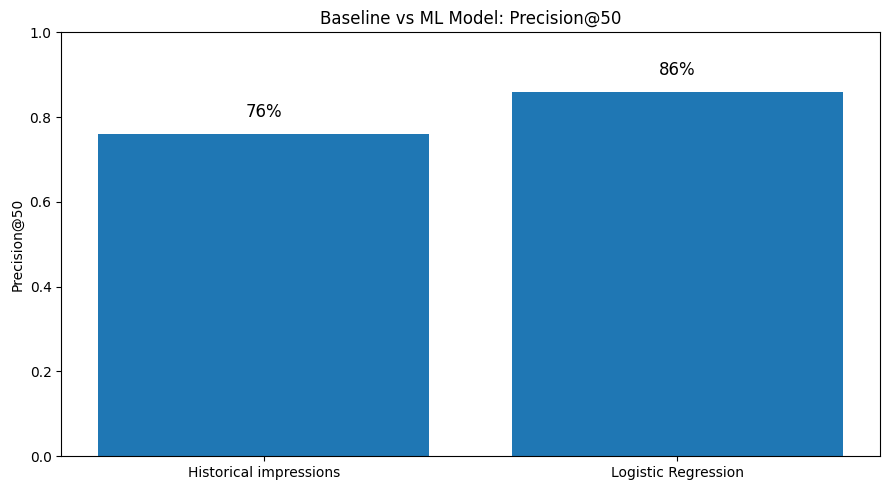

In [42]:
import matplotlib.pyplot as plt

# Baseline vs ML Precision@50

methods = [
    "Historical impressions",
    "Logistic Regression"
]

precision_values = [
    precision_at_50_baseline,
    precision_at_50_model
]

plt.figure(figsize=(9, 5))

bars = plt.bar(methods, precision_values)

plt.ylabel("Precision@50")
plt.title("Baseline vs ML Model: Precision@50")
plt.ylim(0, 1)

# Add percentage labels above each bar
for bar, value in zip(bars, precision_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value * 100:.0f}%",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()

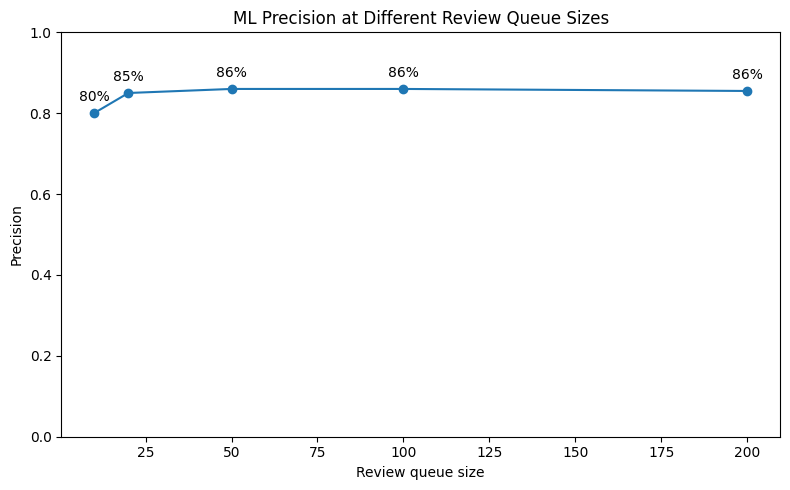

In [43]:
import matplotlib.pyplot as plt

# Precision at different review queue sizes

queue_sizes = [10, 20, 50, 100, 200]

precision_values = [
    model_ranked.head(k)["needs_attention"].mean()
    for k in queue_sizes
]

plt.figure(figsize=(8, 5))

plt.plot(
    queue_sizes,
    precision_values,
    marker="o"
)

plt.xlabel("Review queue size")
plt.ylabel("Precision")
plt.title("ML Precision at Different Review Queue Sizes")
plt.ylim(0, 1)

# Add percentage labels
for x, y in zip(queue_sizes, precision_values):
    plt.text(
        x,
        y + 0.03,
        f"{y:.0%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

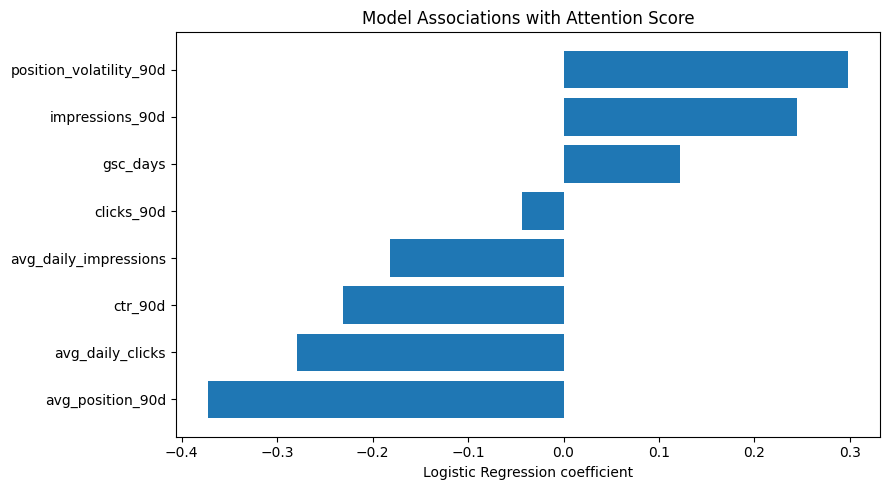

In [44]:
import matplotlib.pyplot as plt

# Model coefficient magnitude

coef_plot = coefficients.sort_values(
    "coefficient"
)

plt.figure(figsize=(9, 5))

plt.barh(
    coef_plot["feature"],
    coef_plot["coefficient"]
)

plt.xlabel("Logistic Regression coefficient")
plt.title("Model Associations with Attention Score")

plt.tight_layout()
plt.show()

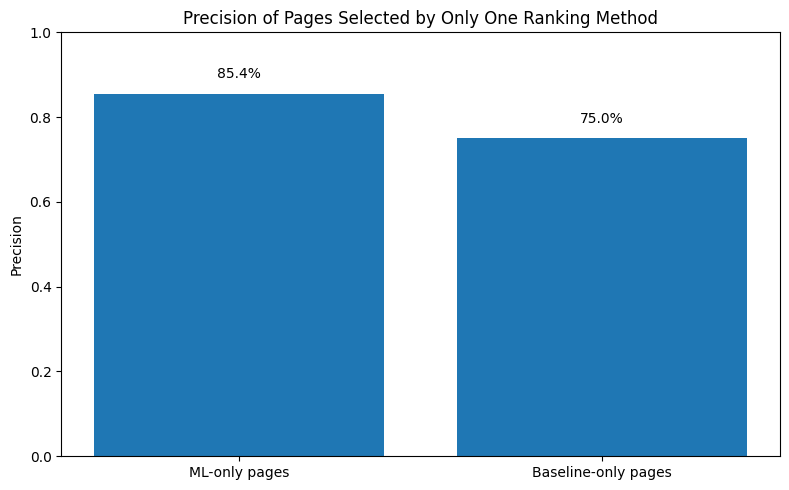

In [45]:
import matplotlib.pyplot as plt

# Compare pages selected only by the ML model
# versus pages selected only by the baseline.

groups = [
    "ML-only pages",
    "Baseline-only pages"
]

precision_values = [
    model_only_data["needs_attention"].mean(),
    baseline_only_data["needs_attention"].mean()
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    groups,
    precision_values
)

plt.ylabel("Precision")
plt.title("Precision of Pages Selected by Only One Ranking Method")
plt.ylim(0, 1)

for bar, value in zip(bars, precision_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [46]:
import pandas as pd

# Create a compact table summarizing the main capstone results.

results_table = pd.DataFrame({
    "Method": [
        "Historical impressions baseline",
        "Logistic Regression"
    ],
    "Precision@50": [
        precision_at_50_baseline,
        precision_at_50_model
    ],
    "Attention pages in top 50": [
        int(top_50_baseline["needs_attention"].sum()),
        int(top_50_model["needs_attention"].sum())
    ]
})

results_table["Precision@50"] = (
    results_table["Precision@50"].map(lambda x: f"{x:.1%}")
)

print("=== RESULTS SUMMARY ===")
display(results_table)

=== RESULTS SUMMARY ===


,Method,Precision@50,Attention pages in top 50
0,Historical impressions baseline,76.0%,38
1,Logistic Regression,86.0%,43


## Artifacts the paper embeds

The following artifacts summarize the main findings of the analysis:

1. **Baseline vs ML Precision@50**
   - Compares the historical-impressions baseline with the Logistic Regression model at the 50-page review budget.
   - The baseline achieved 76.0% Precision@50, while the model achieved 86.0%.

2. **Precision across review queue sizes**
   - Shows model precision for review queues of 10, 20, 50, 100, and 200 pages.
   - Precision remained between 80.0% and 86.0% across these queue sizes.

3. **Model coefficient chart**
   - Shows the direction and relative magnitude of the Logistic Regression coefficients.
   - These coefficients describe model associations with the attention label and should not be interpreted as causal effects.

4. **ML-only vs baseline-only comparison**
   - Compares pages selected exclusively by each ranking approach.
   - The ML-only group had 41 of 48 pages meeting the attention criterion, compared with 36 of 48 for the baseline-only group.

5. **Results summary table**
   - Provides the main Precision@50 and top-50 attention counts in a compact form.

In [47]:
# Final artifact inventory

artifacts = pd.DataFrame({
    "Artifact": [
        "Baseline vs ML Precision@50",
        "Precision across review queue sizes",
        "Model coefficient chart",
        "ML-only vs baseline-only comparison",
        "Results summary table"
    ],
    "Purpose": [
        "Compare the ML model with the historical-impressions baseline",
        "Show how model precision changes with review queue size",
        "Show model associations with the attention label",
        "Compare pages uniquely selected by each ranking method",
        "Summarize the main numerical results"
    ]
})

print("=== CAPSTONE ARTIFACTS ===")
display(artifacts)

=== CAPSTONE ARTIFACTS ===


,Artifact,Purpose
0,Baseline vs ML Precision@50,Compare the ML model with the historical-impre...
1,Precision across review queue sizes,Show how model precision changes with review q...
2,Model coefficient chart,Show model associations with the attention label
3,ML-only vs baseline-only comparison,Compare pages uniquely selected by each rankin...
4,Results summary table,Summarize the main numerical results


In [48]:
# Final capstone self-check

required_variables = [
    "features",
    "outcomes",
    "outcome_table",
    "model_data",
    "train_data",
    "test_data",
    "model",
    "model_ranked",
    "review_queue",
    "results_table"
]

print("=== CAPSTONE SELF-CHECK ===")
print()

all_present = True

for variable in required_variables:
    if variable in globals():
        print(f"✓ {variable}")
    else:
        print(f"✗ {variable} is missing")
        all_present = False

print()

if all_present:
    print("STATUS: All required outputs are present.")
else:
    print("STATUS: Some required outputs are missing.")

print()
print("=== KEY RESULTS ===")
print(f"Baseline Precision@50: {precision_at_50_baseline:.3f}")
print(f"ML Precision@50:       {precision_at_50_model:.3f}")
print(f"Improvement:           {precision_at_50_model - precision_at_50_baseline:+.3f}")
print(f"Test pages:            {len(test_data):,}")
print(f"Review queue size:     {len(review_queue):,}")

=== CAPSTONE SELF-CHECK ===

✓ features
✓ outcomes
✓ outcome_table
✓ model_data
✓ train_data
✓ test_data
✓ model
✓ model_ranked
✓ review_queue
✓ results_table

STATUS: All required outputs are present.

=== KEY RESULTS ===
Baseline Precision@50: 0.760
ML Precision@50:       0.860
Improvement:           +0.100
Test pages:            970
Review queue size:     970


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.